Failure Analysis and Robustness Analysis

This script first perform failure analysis for proportional controller, SAC, and residual SAC, and then perform rebustness analysis under observation noise, action noise, and action scale

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

## Functions

In [2]:
def errorAnalysisFunc(folder = 'baseline', action_path = "actions_proportional_kp_20.0", 
                      achieved_goals_path = "achieved_goals_proportional_kp_20.0", title="Proportional Controller Kp = 20.0",
                      figure_path = None):
    """
    This function analyze the failure cases based on recorded actions and achieved goals.
    Input:
        folder: the folder of the data
        action_path: the prefix of the filename of the recorded actions.
        achieved_goals_path: the prefix of the filename of the recorded achieved goals, ie., where the end effector is.
        title: the title of the figure.
    Output:
        fail_list: the list of the failed cases
    """
    fail_list = []
    fig = plt.figure(figsize=[12,20])
    axes = fig.subplots(4, 2)
    
    for epx in range(100):
        epx_label = '000' + str(epx)
        epx_label = epx_label[-3:]
        path_action = f"../metrics/{folder}/{action_path}_episode_{epx_label}.npy"
        actions = np.load(path_action)
        path_achieved_goals = f"../metrics/{folder}/{achieved_goals_path}_episode_{epx_label}.npy"
        achieved_goals  = np.load(path_achieved_goals)
        if np.linalg.norm(achieved_goals[-1,:3]-target_goals[epx_label]) > 0.005:
            fail_list.append(epx)
        
        axes[0,0].plot(np.linalg.norm(actions[:,:3], axis=1), label=f"{epx_label}")
        axes[1,0].plot(np.abs(actions[:, 0]), label=f"{epx_label}")
        axes[2,0].plot(np.abs(actions[:, 1]), label=f"{epx_label}")
        axes[3,0].plot(np.abs(actions[:, 2]), label=f"{epx_label}")
    
        axes[0,1].plot(np.linalg.norm(achieved_goals[:,:3]-target_goals[epx_label], axis=1), label=f"{epx_label}")
        axes[1,1].plot(np.abs(achieved_goals[:,0]-target_goals[epx_label][0]), label=f"{epx_label}")
        axes[2,1].plot(np.abs(achieved_goals[:,1]-target_goals[epx_label][1]), label=f"{epx_label}")
        axes[3,1].plot(np.abs(achieved_goals[:,2]-target_goals[epx_label][2]), label=f"{epx_label}")
    
    
    for ax in axes.flatten():
        ax.set_yscale('log')
        _ = ax.set_xlabel('step')
        _ = ax.set_xticks([0,10,20,30,40])
        _ = ax.grid()
    
    _ = axes[0,0].set_title(f'|Action|')
    _ = axes[0,0].set_ylabel(f'Total')
    _ = axes[1,0].set_ylabel(f'X-dir')
    _ = axes[2,0].set_ylabel(f'Y-dir')
    _ = axes[3,0].set_ylabel(f'Z-dir')
    
    
    _ = axes[0,1].set_title(f'|Displacement|')
    _ = axes[0,1].set_ylabel(f'Total')
    _ = axes[1,1].set_ylabel(f'X-dir')
    _ = axes[2,1].set_ylabel(f'Y-dir')
    _ = axes[3,1].set_ylabel(f'Z-dir')
    
    for ax in axes[:,1]:
        ax.axhline(y=0.005, color='gray', linestyle='--')

    fig.suptitle(title, y = 1.00)
    #plt.title(filename, pad=30) 
    fig.tight_layout()
    if figure_path:
        fig.savefig(f'{figure_path}')
    
    return fail_list

In [3]:
def expAnalysisFunc(df_in, exp = "observation_noise", noise = "obs_noise_sigma", if_figure = True, SavingPath = "../plots/robustness/"):
    """
    This function takes in the data collected in the robustness experiment and plots the figure
    Input:
        df_in: the data
        exp: the name of the experiment, including "observation_noise", "action_noise", "action_scale"
        noise: the corresponding colume name recorded the noise, including "obs_noise_sigma", "action_noise_sigma", "action scalre"
        if_figure: True to plot the figure and save at SavingPath
    Output:
        df_data: the dataframe that shows the results for the specific experiment
    """
    df = df_in.copy()
    df_obs_noise = df[df["experiment"] == exp].reset_index(drop=True).copy()
    df_data = df_obs_noise.groupby(["policy",noise]).aggregate({ "success": "mean", "total_return": ["mean","std"], "final_distance": ["mean","std"], "action_smoothness": "mean"}).copy()
    
    data = dict()
    for (policy,sigma) in df_data["success"].index:
        if (policy in data): 
            data[policy]["sigma"].append(sigma)
            data[policy]["success rate"].append(df_data.loc[(policy,sigma),("success","mean")])
        else:
            data[policy] = dict()
            data[policy]["sigma"] = [sigma]
            data[policy]["success rate"] = [df_data.loc[(policy,sigma),("success","mean")]]

    if if_figure:
        marker_dict = {"random": 'x', "proportional":'o', "sac":'s', "residual_sac":"^"}
        for policy in ["random", "proportional", "sac", "residual_sac"]:
            plt.plot(data[policy]['sigma'],data[policy]['success rate'], marker = marker_dict[policy], markersize = 10, label=policy)
        plt.legend()
        plt.xlabel(noise)
        plt.ylabel("Success Rate")
        plt.title(exp)
        plt.yticks([0,0.2,0.4,0.6,0.8,1.0])
        plt.ylim([-0.05,1.05])
        plt.grid()
        plt.tight_layout()
        #plt.savefig(f'{SavingPath}/{exp}.png', transparent=True)
        plt.savefig(f'{SavingPath}/{exp}.png')
    return df_data

## Failure Analysis

In [4]:
# Reading Data
FilePath = "../metrics/baseline/proportional_controller_metrics.csv"
df_baseline = pd.read_csv(FilePath)

In [5]:
# Get Target
target_goals = dict()
for i in range(100):
    epx_label = '000' + str(i)
    epx_label = epx_label[-3:]
    str_form = df_baseline[df_baseline["kp"] == 1.0]['initial_desired'].loc[i]
    target_goals[epx_label] = np.array([np.float32(x) for x in re.findall(r"[\d\.]+", str_form)])

### Proportional Controller

[1, 12, 18, 22, 24, 38, 56, 63, 84, 99]


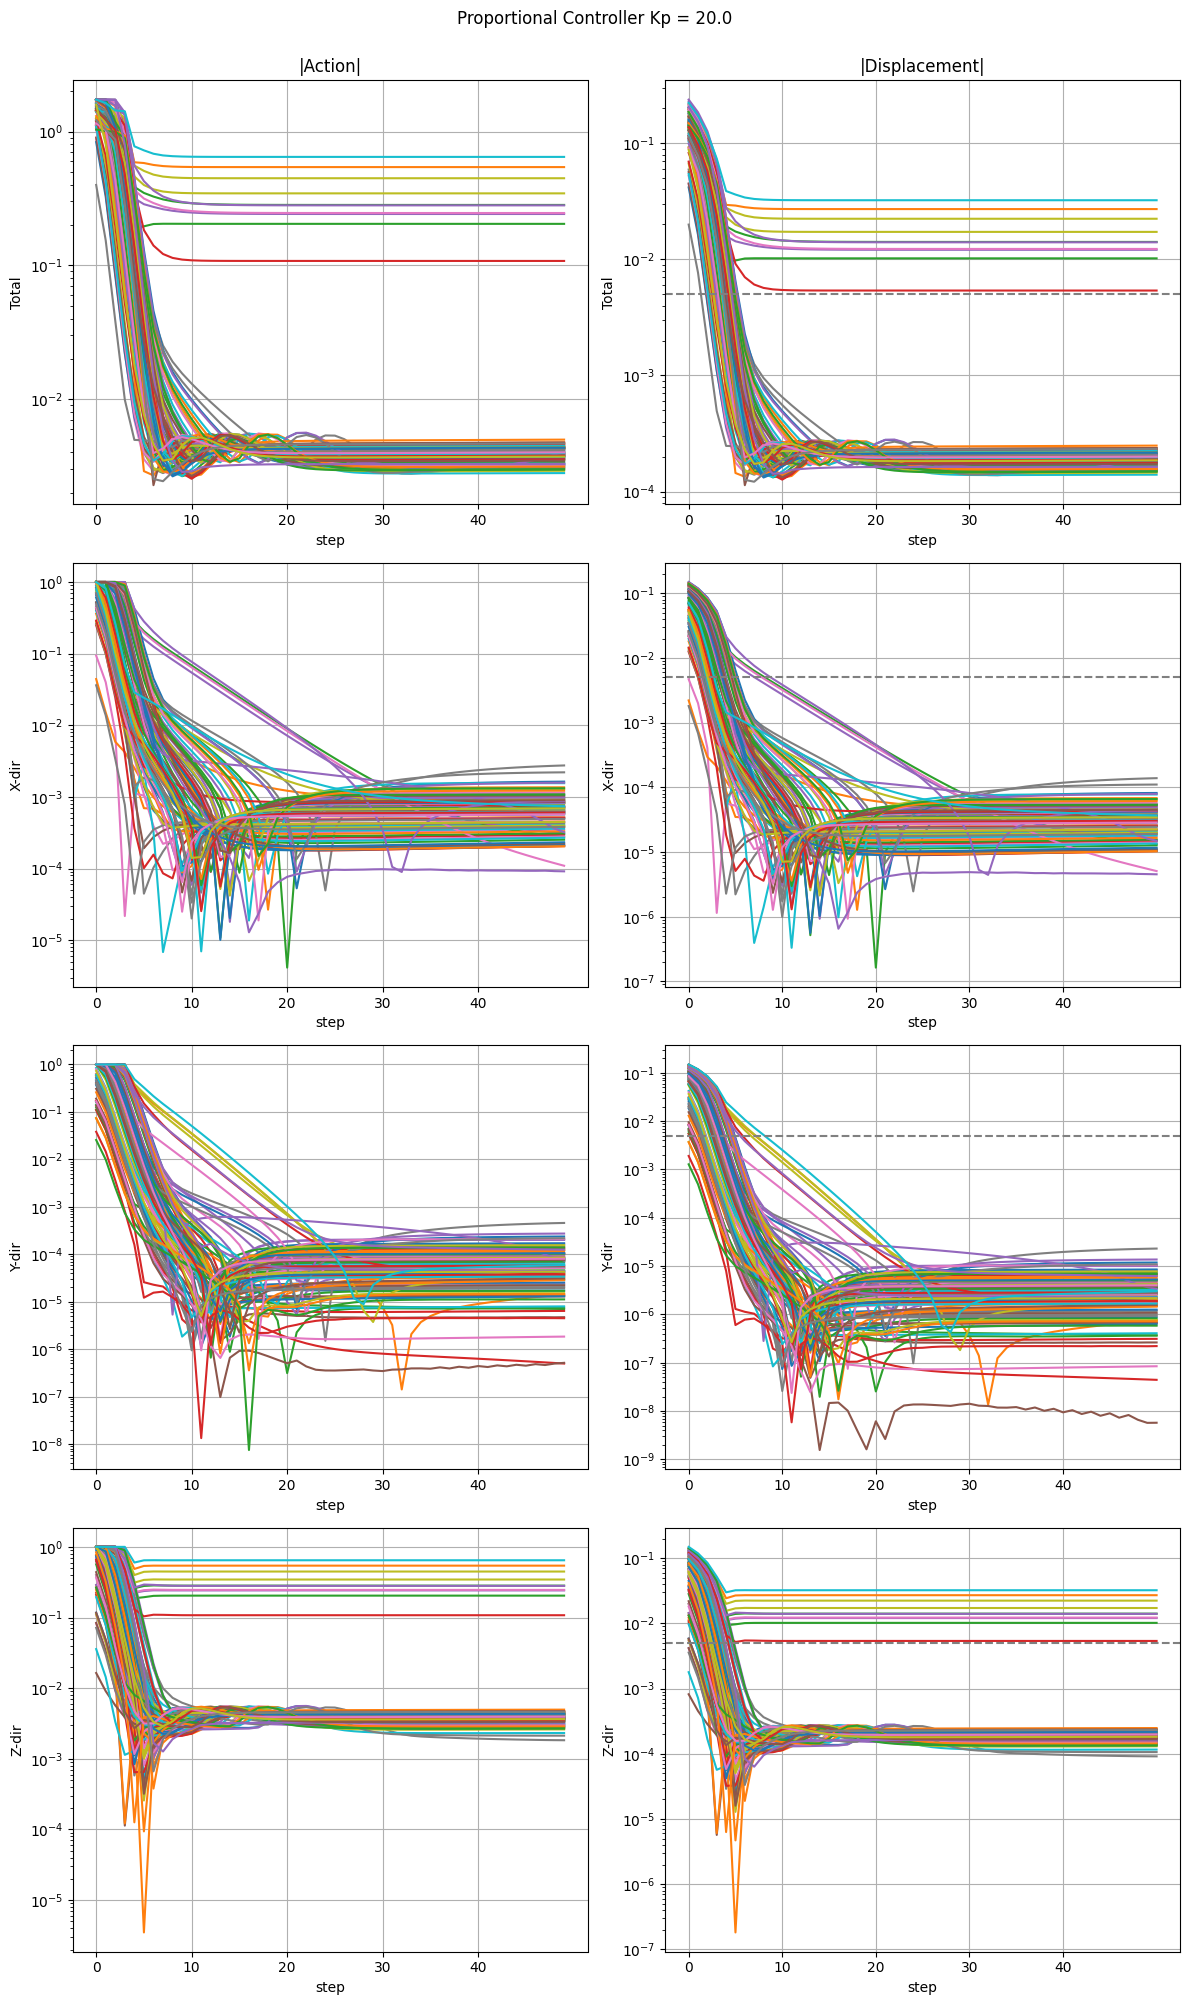

In [6]:
fail_list = errorAnalysisFunc(figure_path = "../plots/baseline/error_analysis_20.png")
print(fail_list)

### SAC

[1, 12, 18, 22, 24, 38, 56, 63, 64, 84, 99]


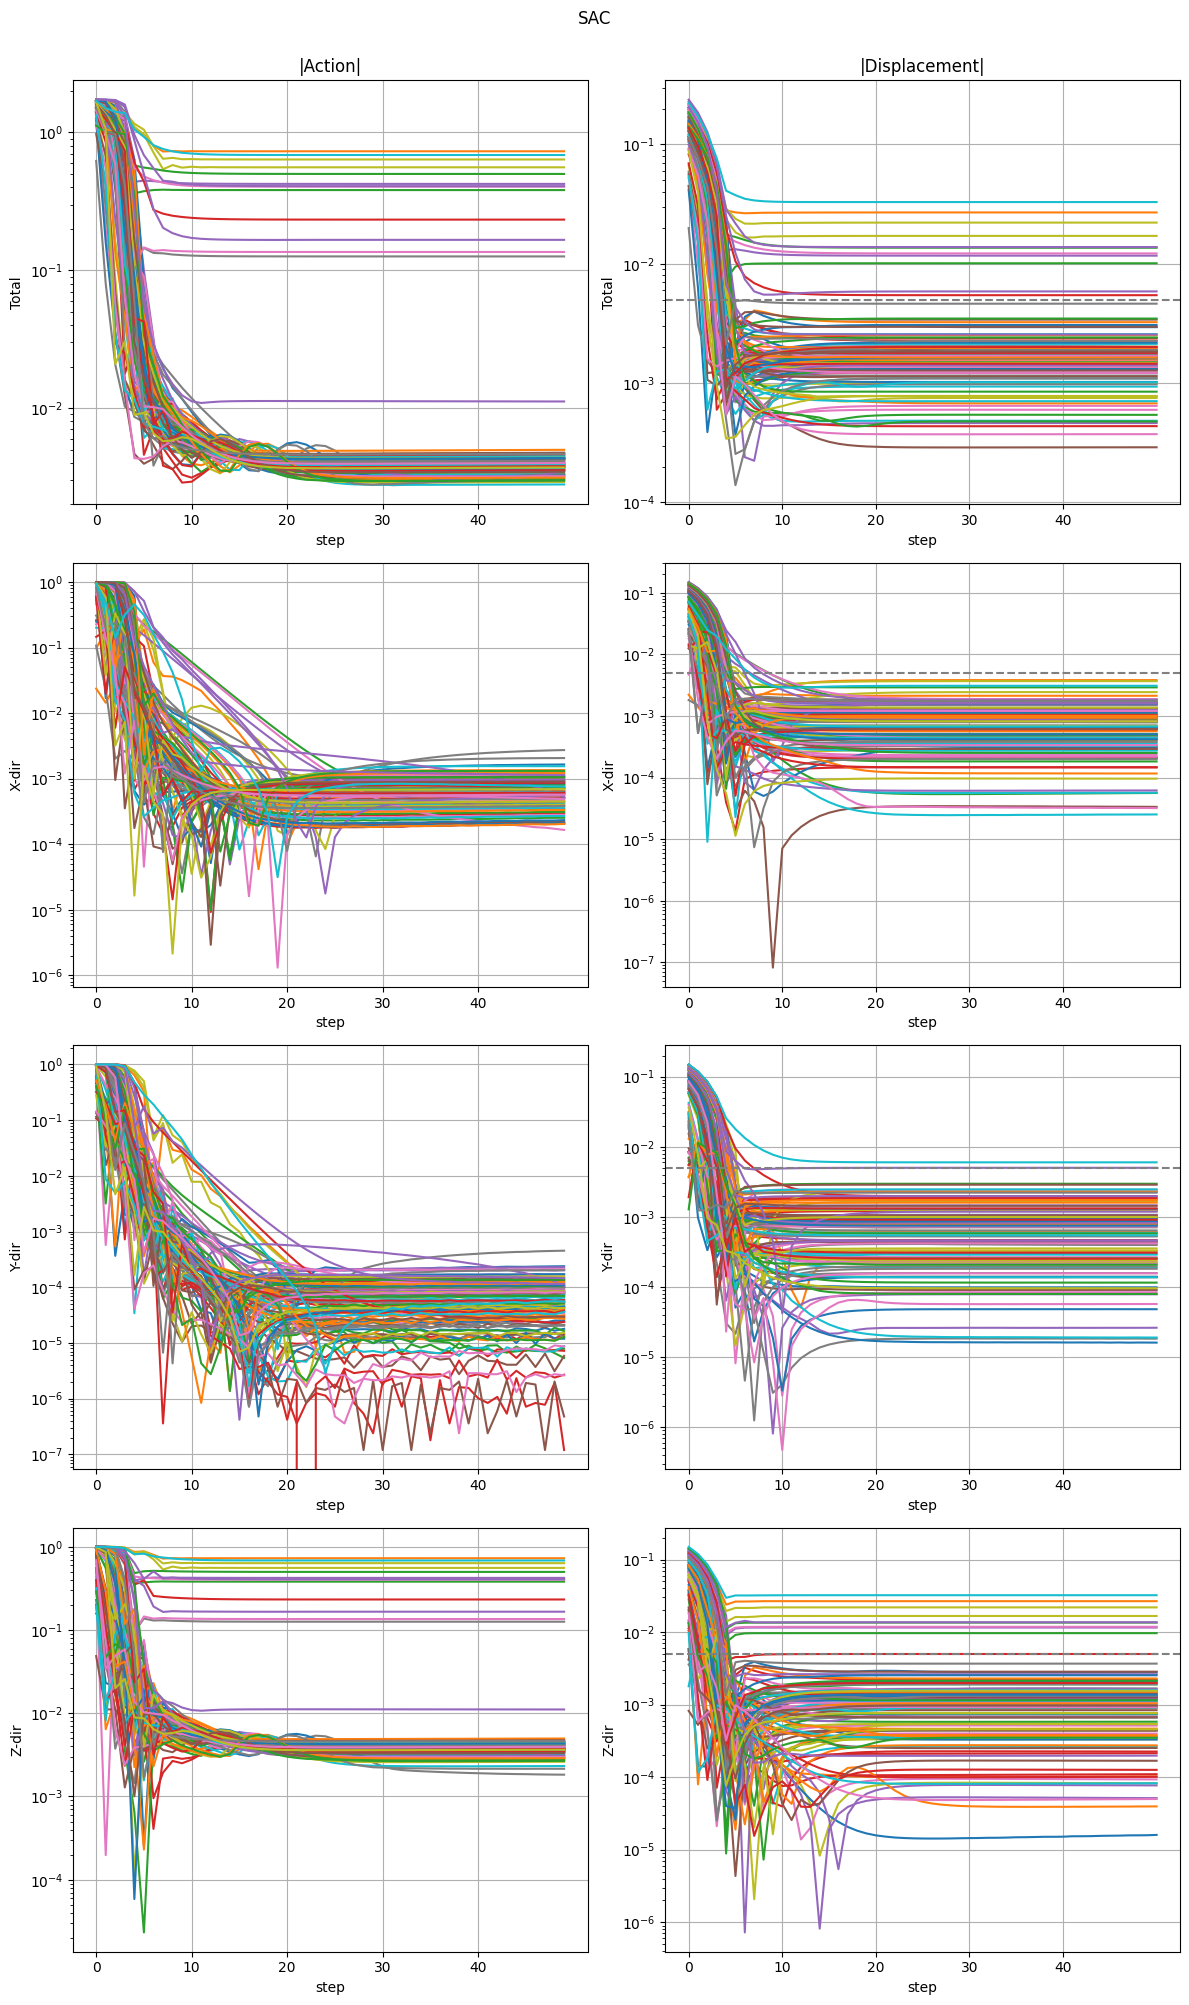

In [7]:
fail_list_SAC = errorAnalysisFunc(folder='sac/auto_auto_150000_20260702-115209', action_path='actions_sac_policy', 
                               achieved_goals_path = 'achieved_goals_sac_policy', title='SAC')
print(fail_list_SAC)

### Residual SAC

[1, 12, 18, 22, 24, 38, 56, 63, 84, 99]


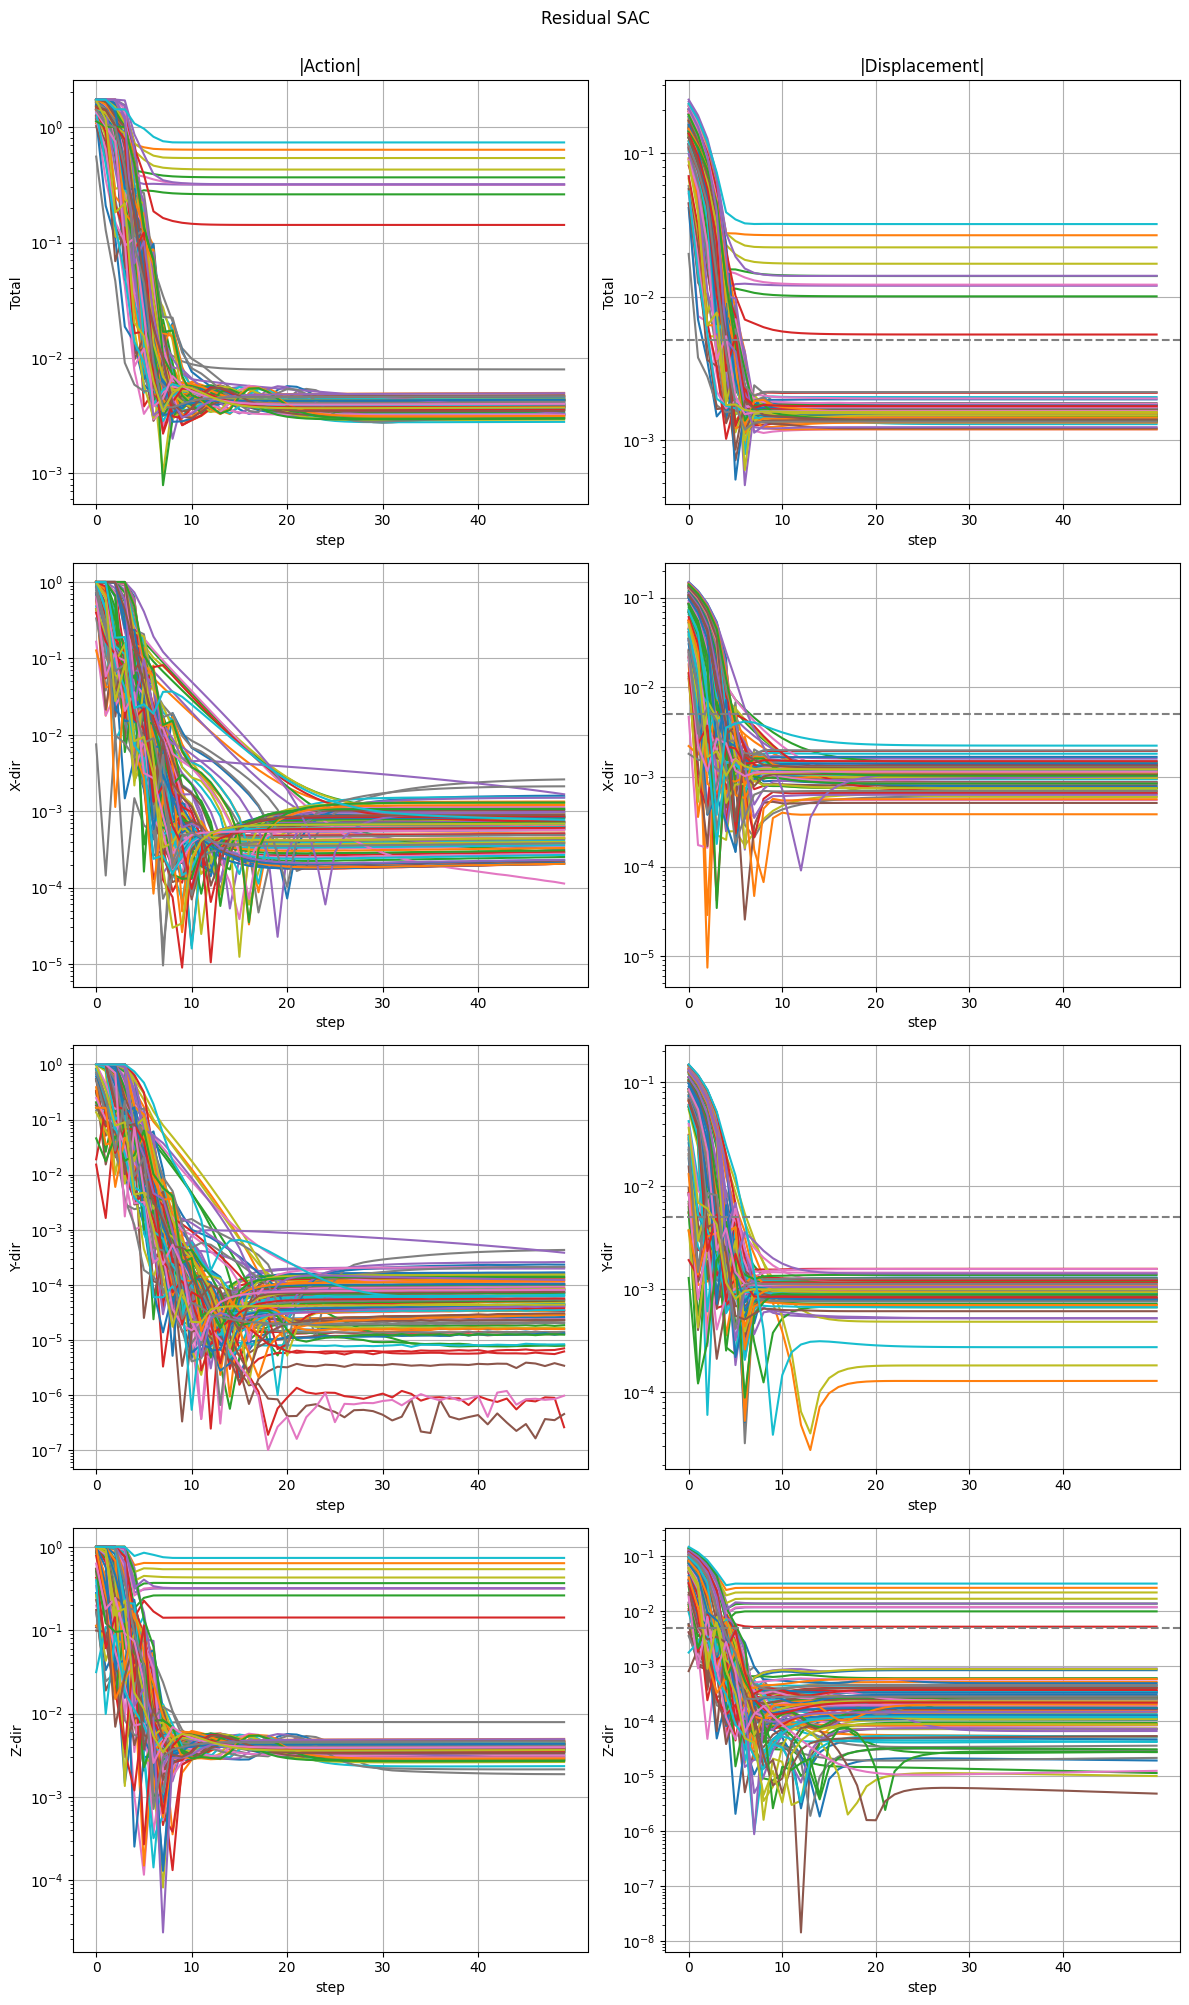

In [8]:
fail_list_r_SAC = errorAnalysisFunc(folder='residual_sac/0.3_auto_auto_150000_20260702-133457', action_path='final_actions_alpha_0.3', 
                               achieved_goals_path = 'achieved_goals_alpha_0.3', title='Residual SAC')
print(fail_list_r_SAC)

#### Checking target's z-coordinates

In [9]:
failed_cases = [1, 12, 18, 22, 24, 38, 56, 63, 84, 99]
data_list = []
for x in range(100):
    epx_label = '000' + str(x)
    epx_label = epx_label[-3:]
    target = target_goals[epx_label]
    data = {'x': target[0], 'y': target[1], 'z': target[2], 'success': True}
    if x in failed_cases:
        data['success'] = False
    data_list.append(data)

df_target = pd.DataFrame(data_list)

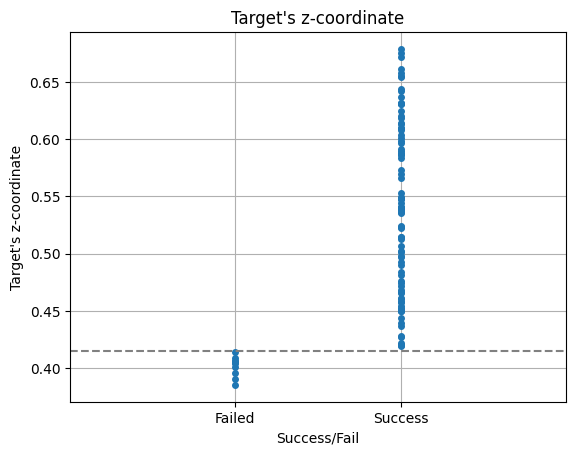

In [10]:
plt.plot(df_target['success'],df_target['z'], linestyle='', marker = 'o', markersize = 4)
plt.xticks(ticks=[0,1], labels=['Failed', 'Success'])
plt.xlim([-1,2])
plt.grid()
plt.axhline(y=0.415, linestyle='--', color = 'grey')
plt.xlabel("Success/Fail")
plt.ylabel("Target's z-coordinate")
plt.title("Target's z-coordinate")
plt.savefig(f'../plots/error-analysis/target_z_coordinate.png')

## Robustness Analysis

In [11]:
# reading file
FilePath = "../metrics/robustness/robustness_metrics.csv"
df = pd.read_csv(FilePath)

### The case without perturbation

In [12]:
df["policy"] = pd.Categorical(df["policy"], categories=["random", "proportional", "sac", "residual_sac"], ordered=True)

In [13]:
df_noiseless = df[(df['experiment'] == "observation_noise") & (df['obs_noise_sigma'] == 0.0) & (df['action_noise_sigma'] == 0.0) & (df['action_scale'] == 1.0)].copy()
df_noiseless["policy"] = pd.Categorical(df_noiseless["policy"], categories=["random", "proportional", "sac", "residual_sac"], ordered=True)

In [14]:
df_noiseless.groupby("policy").aggregate({ "success": "mean", "total_return": ["mean","std"], "final_distance": ["mean","std"], "action_smoothness": "mean"})

success total_return           final_distance            \
                mean         mean       std           mean       std   
policy                                                                 
random          0.00    -9.537993  2.864621       0.217152  0.098033   
proportional    0.90    -0.277452  0.317641       0.001846  0.005565   
sac             0.89    -0.331685  0.308750       0.003145  0.005235   
residual_sac    0.90    -0.330766  0.298172       0.003071  0.005158   

             action_smoothness  
                          mean  
policy                          
random                9.859157  
proportional          0.938811  
sac                   1.228178  
residual_sac          1.245132

### Observation Noise

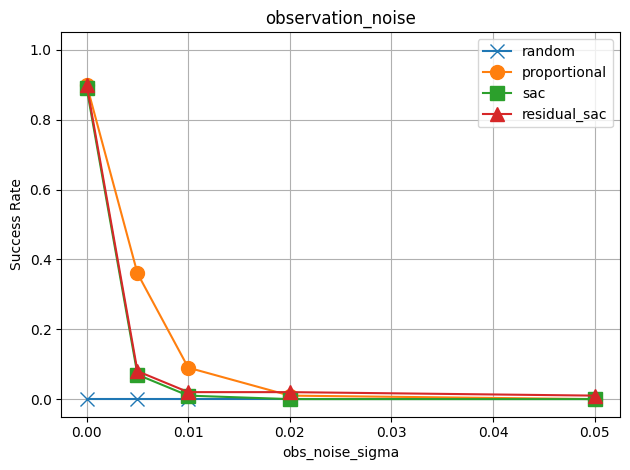

In [15]:
df_data = expAnalysisFunc(df_in=df, exp = "observation_noise", noise = "obs_noise_sigma")

### Action Noise

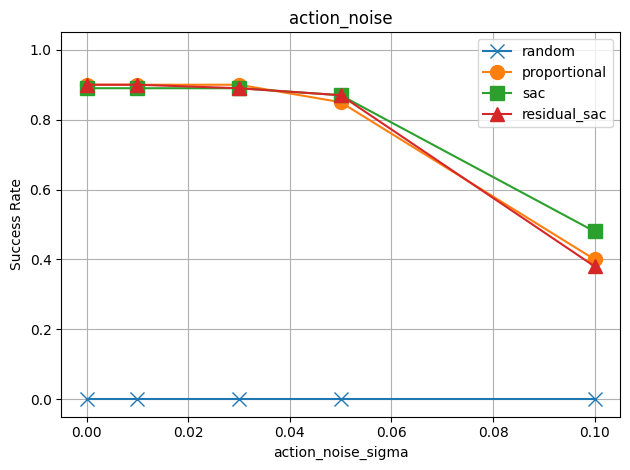

In [16]:
df_data = expAnalysisFunc(df_in=df, exp = "action_noise", noise = "action_noise_sigma")

### Action Scale

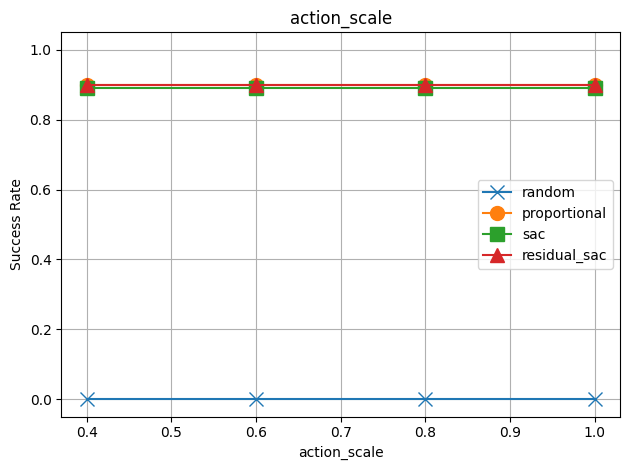

In [17]:
df_data = expAnalysisFunc(df_in=df, exp = "action_scale", noise = "action_scale")